In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("4) house Prediction Data Set.csv",sep=r'\s+',header=None)
print(df.shape)
df.head()

(506, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B',
    'LSTAT', 'MEDV'
]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
X = df.drop('MEDV',axis=1)
print(X.shape)

(506, 13)


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(506, 13)


In [11]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[6578.0, 4196.15929120914, 3514.3904144150883, 3122.4399984151282, 2729.9888527836442, 2441.810184544407, 2201.385712662812, 2078.3683849292643, 1850.0835630412532, 1755.5977213394679]


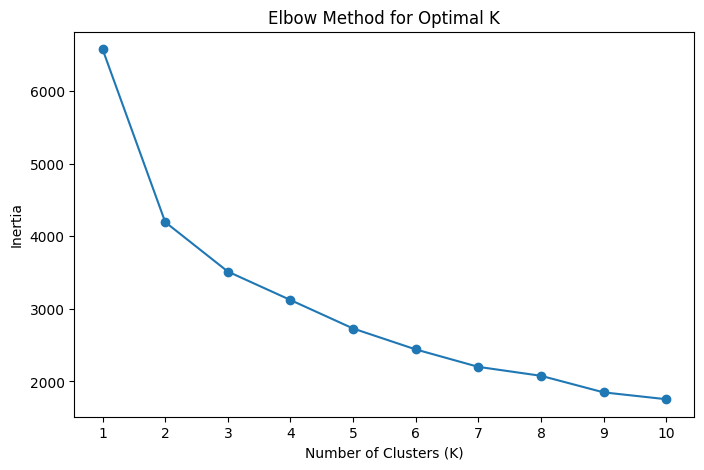

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.savefig("elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  Cluster  
0     15.3  396.90   4.98  24.0        0  
1     17.8  396.90   9.14  21.6        0  
2     17.8  392.83   4.03  34.7        0  
3     18.7  394.63   2.94  33.4        0  
4     18.7  396.90   5.33  36.2        0  


In [15]:
print(df['Cluster'].value_counts())

Cluster
0    243
2    163
1    100
Name: count, dtype: int64


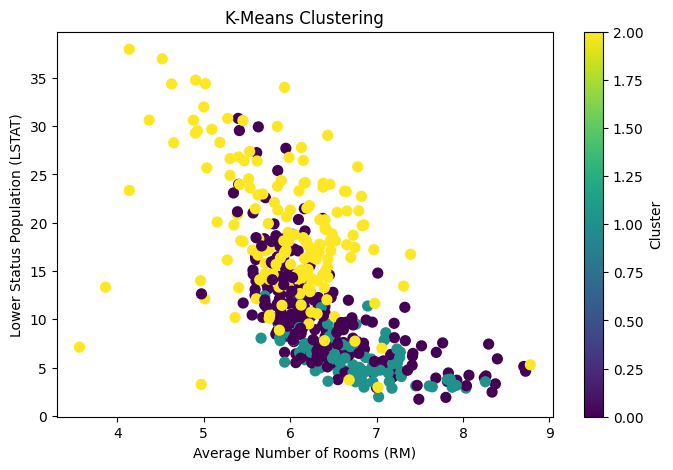

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['RM'],
    df['LSTAT'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Lower Status Population (LSTAT)")
plt.title("K-Means Clustering")
plt.colorbar(label="Cluster")

plt.show()

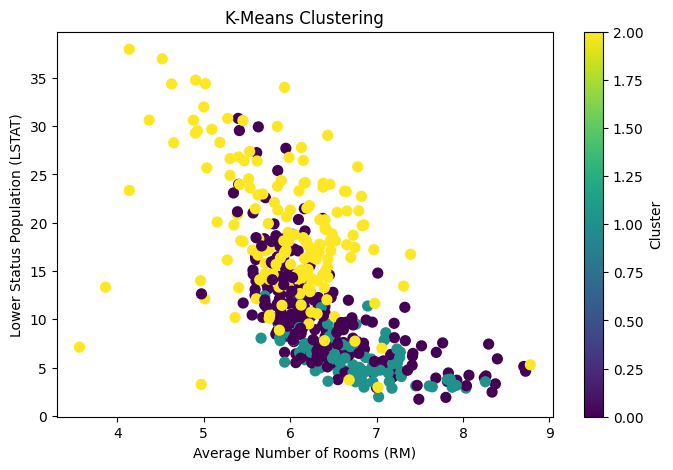

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['RM'],
    df['LSTAT'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Lower Status Population (LSTAT)")
plt.title("K-Means Clustering")
plt.colorbar(label="Cluster")

plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches="tight")

plt.show()

In [19]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[-0.37547882 -0.35313508 -0.31724007  0.01932709 -0.29782329  0.08606488
   0.01486798 -0.01338814 -0.57646038 -0.60934179 -0.13888887  0.28610976
  -0.22580922]
 [-0.41230637  1.65310569 -1.0487349  -0.07554875 -1.11778315  0.55569611
  -1.33451363  1.42565644 -0.61152092 -0.64415772 -0.64431767  0.36068648
  -0.88004791]
 [ 0.8127116  -0.48772236  1.11633636  0.01753614  1.12975077 -0.46922318
   0.79655487 -0.85467684  1.23455192  1.30359403  0.6023421  -0.64781177
   0.87654252]]
